# Imports

In [1]:
import os
import glob
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import math
from functools import partial
import numpy as np
import scipy as sp
import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partial
import datetime
import json
from PIL import Image
from attr import dataclass
import scipy.io as scio
import h5py

import torch
from torch import nn, Tensor, optim
import torch.nn.functional as F
from torchvision import datasets
from torchmetrics.image import MultiScaleStructuralSimilarityIndexMeasure, StructuralSimilarityIndexMeasure
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, StepLR, SequentialLR, LinearLR, OneCycleLR
from torch.utils.data import  DataLoader
from torchvision.transforms import v2
from torchinfo import summary

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, TQDMProgressBar
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger
from torchmetrics.image import StructuralSimilarityIndexMeasure
import pynop

from utils import plot_interactive, plot_comparison, get_simulation_by_id, animate_results_mpl

%matplotlib inline


# Model creation


In [4]:
# Dictionary containing all model configurations
# number of past slice (ground truth) given to the network or latent representation the case of CausalLNO
steps = 6

models_config = {
    "Galerkin": {
        "model": pynop.GalerkinTransformer,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "dt": 5 / 100,
            "num_blocks": 4,
            "hidden_channels": 128,
            "num_heads": 4,
            "mlp_layers": 2,
            "mlp_dim": 256,
            "activation": nn.GELU,
            "mlp_factor": 2,
            "dim": 2,
            "verbose": False,
        },
    },
    "ITLNO": {
        "model": pynop.ITLNO,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "modes": 16,
            "dt": 5 / 100,
            "num_blocks": 4,
            "hidden_channels": 128,
            "num_heads": 4,
            "linear_kernel": False,
            "mlp_layers": 1,
            "mlp_dim": 128,
            "mlp_factor": 2,
            "activation": nn.GELU,
            "mlp_act": nn.GELU,
            "dim": 2,
            "orthogonal_init": True,
            "pe": True,
            "rmsnorm": True,
            "basis_mode": "free",
            "verbose": True,
        },
    },
    "chebITLNO": {
        "model": pynop.ITLNO,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "dt": 5.0 / 100.0,  # final t=5, 101 slices
            "modes": 16,
            "num_blocks": 4,
            "hidden_channels": 128,
            "num_heads": 4,
            "linear_kernel": False,
            "mlp_layers": 1,
            "mlp_dim": 128,
            "mlp_factor": 2,
            "activation": nn.GELU,
            "mlp_act": nn.GELU,
            "dim": 2,
            "orthogonal_init": True,
            "pe": True,
            "basis_mode": "free",
            "rmsnorm": True,
            "verbose": True,
        },
    },
    "LatentGalerkin": {
        "model": pynop.LatentGalerkin,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "modes": 256,
            # "dt": 5 / 100,
            "num_blocks": 4,
            "hidden_channels": 128,
            "num_heads": 4,
            "mlp_layers": 1,
            "mlp_dim": 128,
            "mlp_factor": 2,
            "activation": nn.GELU,
            "mlp_act": nn.GELU,
            "dim": 2,
            "latent_attention": "vanilla",
            "verbose": True,
            "pe": "random_ipe",
            "pe_param":10,
        },
    },
    "Transolver_classic": {
        "model": pynop.Transolver,
        "params": {
            "in_ch": 2 * steps,
            "out_ch": 2,
            "slice_num": 64,
            "n_layers": 8,
            "n_hidden": 128,
            "dropout": 0,
            "n_head": 4,
            "activation": nn.GELU,
            "mlp_ratio": 1,
            "dim": 2,
            "cond_dim": None,
        },
    },
    "Transolver_linear": {
        "model": pynop.Transolver,
        "params": {
            "in_ch": 2 * steps,
            "out_ch": 2,
            "slice_num": 64,
            "n_layers": 8,
            "n_hidden": 128,
            "dropout": 0.05,
            "n_head": 4,
            "mode": "linear",
            "activation": nn.GELU,
            "mlp_ratio": 2,
            "dim": 2,
            "cond_dim": None,
        },
    },
    "LatentTransolver3": {
        "model": pynop.LatentTransolver,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "dt": 5 / 100,
            "modes": 64,
            "num_blocks": 4,
            "hidden_channels": 128,
            "dropout": 0.05,
            "num_heads": 4,
            "activation": nn.GELU,
            "mlp_act": nn.GELU,
            "mlp_factor": 2,
            "dim": 2,
            "cond_dim": None,
            "rmsnorm": True,
            "std_init": 1e-3,
            "verbose": True,
        },
    },
    "FNO": {
        "model": pynop.FNO,
        "params": {
            "in_channels": 2 * steps,
            "out_channels": 2,
            "modes": (16, 16),
            "hidden_channels": (36, 36, 36, 36),
            "blocks": ["FNO", "FNO", "FNO", "FNO"],
            "spectral_compression_factor": (1, 1, 1),
            "trainable_pos_encoding": False,
            "fixed_pos_encoding": True,
            "trainable_pos_encoding_modes": (16, 16),
            "trainable_pos_encoding_dims": 8,
        },
    # },"TimeAttentionLatentGalerkin": {
    #     "model": pynop.TimeAttentionLatentGalerkin,
    #     "params": {
    #         "in_channels": 2,
    #         "out_channels": 2,
    #         "modes": 128,
    #         "dt": 5 / 100,
    #         "num_blocks": 4,
    #         "hidden_channels": 128,
    #         "num_heads": 4,
    #         "mlp_layers": 1,
    #         "mlp_dim": 128,
    #         "mlp_factor": 2,
    #         "activation": nn.GELU,
    #         "mlp_act": nn.GELU,
    #         "dim": 2,
    #         "latent_attention": "galerkin",
    #         "verbose": True,
    #         "memory": steps,
    #     },
    },
}

# name = "ITLNO"
# name = "chebITLNO"
# name = 'Transolver_classic'
# name = "Transolver_linear"
# name = 'FNO'
# name = "LatentTransolver3"
# name = "Galerkin"
name = "LatentGalerkin"
# name = "TimeAttentionLatentGalerkin"

# Instantiate model
if name == "CLNO" or name == "TimeAttentionLatentGalerkin":
    in_steps = 1
else:
    in_steps = steps

model = models_config[name]["model"](**models_config[name]["params"]).to("cuda")

TypeError: LatentGalerkin.__init__() got an unexpected keyword argument 'mlp_layers'

In [ ]:
# summary(model, input_size=(1,2,128,128))
data = torch.rand((2, 2*in_steps, 128, 128)).to("cuda")
time = torch.rand(2).unsqueeze(-1).float().to("cuda")
if name == "FNO":
    print(summary(model, input_data=data, depth=4, col_names=("input_size", "output_size", "num_params")))
elif name == "TimeAttentionLatentGalerkin":
    _, history = model(x=data, time=time)
    print(summary(model, input_data=(data, time, history), depth=4, col_names=("input_size", "output_size", "num_params")))
else:
    print(summary(model, input_data=(data, time), depth=4, col_names=("input_size", "output_size", "num_params")))


# Load the model from config

In [12]:
run_dir = Path("/home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/LatentGalerkin/10steps_20260612-172406")
run_number = "20260612-172408"
with open(run_dir / f"{run_number}-config.json", "r") as f:
    model_config = json.load(f)

with open(run_dir / f"{run_number}-hyperparams.json", "r") as f:
    hyperparams = json.load(f)

with open(run_dir / f"{run_number}-train_config.json", "r") as f:
    train_config = json.load(f)
import inspect

def parse_activation(x):
    if x is None or not isinstance(x, str):
        return x
    if "GELU" in x:
        return nn.GELU
    if "ReLU" in x:
        return nn.ReLU
    if "SiLU" in x:
        return nn.SiLU
    raise ValueError(f"Unknown activation: {x}")

def clean_params(model_class, params):
    params = params.copy()

    for key in ["activation", "mlp_act"]:
        if key in params:
            params[key] = parse_activation(params[key])

    sig = inspect.signature(model_class.__init__)
    allowed = set(sig.parameters.keys()) - {"self"}

    removed = sorted(set(params) - allowed)
    params = {k: v for k, v in params.items() if k in allowed}

    print("Removed keys:", removed)
    return params

model_name = "LatentGalerkin"
model_class = pynop.LatentGalerkin

params = clean_params(model_class, model_config["params"])

model = model_class(**params).to("cuda")
model.eval()

Removed keys: ['mlp_dim', 'mlp_layers']


LatentGalerkin(
  (lifting): Linear(in_features=20, out_features=128, bias=True)
  (pelayer): PEBlock(
    (pe): GaussianIntegratedPositionalEncoding()
  )
  (mixer): MLPBlock(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (encoder): GalerkinAttention(
    (to_q): Linear(in_features=128, out_features=128, bias=True)
    (to_k): Linear(in_features=128, out_features=128, bias=True)
    (to_v): Linear(in_features=128, out_features=128, bias=True)
    (out_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (decoder): GalerkinAttention(
    (to_q): Linear(in_features=128, out_features=128, bias=True)
    (to_k): Linear(in_features=128, out_features=128, bias=True)
    (to_v): Linear(in_features=128, out_features=128, bias=True)
    (out_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (backward_queries_pred

# Data loading, creation of the train/val sets and dataloaders

In [ ]:
# datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
# stats=pynop.inspect_PDEBenchDataset(datapath, DT=5e-2)
# print(stats)
# With DT=5/100²
# ==================================================
#               PDEBENCH INSPECTION REPORT
# ==================================================
# Simulations : 1000
# Time steps  : 101
# Resolution  : (128, 128)
# Channels    : 2
# --------------------------------------------------
# CHANNEL 0:
#   [Values] Min: -5.2797 | Max: 5.5866
#   [Values] Mean: -0.0311 | Std: 0.1436
#   [Deriv ] Mean: -0.014908 | Std: 1.962596
# --------------------------------------------------
# CHANNEL 1:
#   [Values] Min: -5.3747 | Max: 5.1440
#   [Values] Mean: -0.0199 | Std: 0.1113
#   [Deriv ] Mean: -0.011219 | Std: 1.992754
# --------------------------------------------------
# ==================================================

In [ ]:
# datapath = Path("F:/Projets/2D_diff-react_NA_NA.h5")
# datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
datapath = Path("/home/armature/Downloads/2D_diff-react_NA_NA.h5")
# stats du dataset
# 'global_min': array([-5.279711 , -5.3747244], dtype=float32),
# 'global_max': array([5.5866303, 5.1440244], dtype=float32)

# shift = 5.59
# scale = 0.5
std = (0.1113 + 0.1436) * 0.5
shift = 0  # -> values > 0
scale = 1 #/ std  # Division by the std to get std=1

unrolling = 10

train_set = pynop.PDEBenchDataSet(
    datapath,
    T_unroll=unrolling + steps,
    step=8,
    load_in_ram=True,
    split_type="train",
    split_ratio=0.9,
    n_samples=100,
    seed=42,
    min_id=2,
    max_id=70,
    shift=shift,
    scale=scale,
)
val_set = pynop.PDEBenchDataSet(
    datapath,
    T_unroll=unrolling + steps,
    step=8,
    load_in_ram=True,
    split_type="val",
    split_ratio=0.9,
    n_samples=100,
    seed=42,
    min_id=2,
    max_id=70,
    shift=shift,
    scale=scale,
)
print(len(train_set))

In [9]:
# datapath = Path("F:/Projets/2D_diff-react_NA_NA.h5")
# datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
datapath = Path("/home/armature/Downloads/2D_diff-react_NA_NA.h5")
# stats du dataset
# 'global_min': array([-5.279711 , -5.3747244], dtype=float32),
# 'global_max': array([5.5866303, 5.1440244], dtype=float32)

# shift = 5.59
# scale = 0.5
steps = hyperparams["steps"]          # 10
shift = hyperparams["shift"]          # 0
scale = hyperparams["scale"]          # 1
unrolling = train_config["n_slices"]  # 10
valid_idx = hyperparams["valid_idx"]
# print(valid_idx)
# val_set = pynop.PDEBenchDataSet(
#     datapath,
#     T_unroll=unrolling + steps,  # 20
#     step=8,
#     load_in_ram=True,
#     split_type="val",
#     split_ratio=0.9,
#     n_samples=100,
#     seed=42,
#     min_id=2,
#     max_id=70,
#     shift=shift,
#     scale=scale,
# )

# print(len(train_set))

val_set = pynop.PDEBenchDataSet(
    datapath,
    T_unroll=unrolling + steps,
    step=8,
    load_in_ram=True,
    indexes=valid_idx,
    min_id=0,
    max_id=None,
    shift=shift,
    scale=scale,
)

print(len(val_set))

Scanning samples: 100%|██████████| 4/4 [00:00<00:00, 129.66it/s]

Dataset initialized with 4 simulations.
Total unrolled windows: 44
Status: RAM mode.
44


In [10]:
batch_size = 1
# train_dataloader = DataLoader(train_set, shuffle=True, batch_size=batch_size, num_workers=10)
valid_dataloader = DataLoader(
    val_set, shuffle=False, batch_size=batch_size, num_workers=10, persistent_workers=True, pin_memory=True
)

/home/armature/miniforge3/envs/pytorch/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Preparing the training
**Notes:**

- It seems better to use the class `pynop.nL2Loss` or `pynop.nMSELoss` for the loss. It computes the normalized MSE or RMSE *by canal* (i.e. for each physical variable), especially if the variables have different order of magnitude.

- The metric RMSE, which is logged during training, is a mean over all spatial, channel and batch dimension. It is used here as it is often the metric given in the papers.

- Most of the  benchmarks use at least 10 previous time steps as input to predict the next time step.
- In Transolver, LNO and LinearNO, they mostly use Onecycle scheduler without curriculum training (full 10 timesteps rollout  at first epoch). 

## Freeze layers

In [ ]:
# for named_param, param in model.named_parameters():
#     # Only allow gradients for the temporal block
#     # OR if it's a normalization layer (optional strategy)
#     if "temporal_block" in named_param or "norm" in named_param:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# print("Trainable parameters:")
# for named_param, param in model.named_parameters():
#     if param.requires_grad:
#         print(f"{named_param}")

In [ ]:
from pynop import ITLNOGradientLogger
exp = "fullds"  # root directory
weight_decay = 1e-4
max_epochs = 250
lr = 1e-3  # This is the maximum learning rate
start_monitoring = 70  # start saving the best models only after this epoch
mse_shift = 0
mse_scale = 1
residual = False

# pynop.nDWMSELoss(shift=mse_shift, scale=mse_scale),
# pynop.SpectralLoss( beta=1),
# pynop.SobolevLoss(l1=1., l2=1.),
# pynop.nMSELoss(),
# torch.nn.MSELoss(),
# nn.L1Loss() better for autoencoder

def SSMLoss(preds, targets):
    SSM = StructuralSimilarityIndexMeasure().to("cuda")
    return 1 - SSM(preds, targets)

print("steps", steps)

train_config = pynop.TrainingConfig(
    start_autoregressive=0,  # epoch at which the AR steps starts increasing
    final_autoregressive=80,
    min_autoregressive_steps=4,  # number of AR steps before start_autoregressive
    max_autoregressive_steps=unrolling,
    detach_grad_steps=40,
    derivative_loss_weight=1,
    loss_fn=[pynop.DWMSELoss(), pynop.SpectralLoss(beta=2)],
    loss_weights=[1000, 1000],
    noise_level=std*1e-2,
    time_normalization=101,
    n_slices=steps,  # number of previous time steps used to predict the next one
    temporal_weighting=1.05,
    train_mode="predict",  # only useful for Causal NO Models: if train_mode=='autoencoder', the Temporalmodule is disabled
)

scheduler_config = [
    {
        "scheduler": OneCycleLR,
        "max_lr": lr,
        "div_factor": 1e3,
        "final_div_factor": 1e3,
        "pct_start": 0.05,
        "interval": "step",
        "total_steps": max_epochs * len(train_dataloader),
        "frequency": 1,
    },
]



print("Total number of steps:", max_epochs * len(train_dataloader))
# model_name = model.__class__.__name__
model_name = name
loss_name = str(type(train_config.loss_fn)).split(".")[-1]
folder = f"{model_name}"  # _{loss_name}"
folder = Path(folder)
now = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
baselogdir = Path("/media/jlux/SSD2/ReactionDiffusion/") / Path(exp) / folder
logdir = Path(baselogdir / Path(f"{steps}steps_{now}"))
# logdir = Path("/media/jlux/SSD2/ReactionDiffusion/fullds/ITLNO_res/20260223-202651")
callbacks = []

loggers = [TensorBoardLogger(logdir / Path("tb_logs")), CSVLogger(logdir)]

callbacks.append(
    ModelCheckpoint(
        monitor="val_loss", filename=os.path.join(logdir, "best_val_loss"), mode="min", save_top_k=2, save_last=False
    )
)

callbacks.append(
    pynop.CurriculumCheckpoint(
        start_epoch=start_monitoring,
        monitor="loss",
        filename=os.path.join(logdir, "best_train_loss"),
        mode="min",
        save_top_k=2,
        save_last=False,
    )
)
callbacks.append(
    pynop.CurriculumCheckpoint(
        start_epoch=start_monitoring,
        dirpath=logdir,
        filename="last",
        every_n_epochs=1,
        save_top_k=1,
        mode="max",
    )
)

callbacks.append(LearningRateMonitor(logging_interval="epoch"))

# print values in scientific format
class CustomProgressBar(TQDMProgressBar):
    def get_metrics(self, trainer, model):
        items = super().get_metrics(trainer, model)
        # On applique le format scientifique à tout le dictionnaire
        return {k: (f"{v:.3e}" if isinstance(v, float) else v) for k, v in items.items()}

callbacks.append(CustomProgressBar(leave=True))

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad and p.ndim != 2, model.parameters()),
    lr=lr,
    weight_decay=weight_decay,
    betas=(0.9, 0.99),
)



if name =="TimeAttentionLatentGalerkin":
    lightning_model = pynop.CausalNOModel(
        model=model, train_config=train_config, optimizer=optimizer, scheduler_config=scheduler_config
    )
else:
    lightning_model = pynop.MultiStepNOModel(
        model=model, train_config=train_config, optimizer=optimizer, scheduler_config=scheduler_config
    )

# --------------------- Load checkpoint here ---------------------
# checkpoint = torch.load(Path("/media/jlux/SSD2/ReactionDiffusion/fullds/LatentGalerkin/8steps_20260320-150930") / Path("last.ckpt"))
# lightning_model.load_state_dict(checkpoint['state_dict'])
# --------------------- load the optimizer checkpoint to continue a previous run ---------------------
# optimizer.load_state_dict(checkpoint['optimizer_states'][0])

torch.set_float32_matmul_precision("highest")
# torch.set_float32_matmul_precision("high")

trainer = pl.Trainer(
    max_epochs=max_epochs,
    # limit_train_batches=0.5,
    callbacks=callbacks,
    accelerator="gpu",
    logger=loggers,
    num_sanity_val_steps=0,
    log_every_n_steps=50,
    gradient_clip_val=1,
    gradient_clip_algorithm="norm",
)

print("Log dir:", logdir)

In [13]:
def make_loss(name):
    if name == "DWMSELoss":
        return pynop.DWMSELoss()
    elif name == "SpectralLoss":
        return pynop.SpectralLoss(beta=2)
    elif name == "SobolevLoss":
        return pynop.SobolevLoss()
    elif name == "nMSELoss":
        return pynop.nMSELoss()
    else:
        raise ValueError(f"Unknown loss: {name}")

train_config = pynop.TrainingConfig(
    dt=train_config["dt"],
    start_autoregressive=train_config["start_autoregressive"],
    final_autoregressive=train_config["final_autoregressive"],
    min_autoregressive_steps=train_config["min_autoregressive_steps"],
    max_autoregressive_steps=train_config["max_autoregressive_steps"],
    detach_grad_steps=train_config["detach_grad_steps"],
    derivative_loss_weight=train_config["derivative_loss_weight"],
    loss_fn=[make_loss(name) for name in train_config["loss_fn"]],
    loss_weights=train_config["loss_weights"],
    noise_level=train_config["noise_level"],
    time_normalization=train_config["time_normalization"],
    n_slices=train_config["n_slices"],
    temporal_weighting=train_config["temporal_weighting"],
)
optimizer = torch.optim.AdamW(model.parameters(), lr=hyperparams["lr0"])

lightning_model = pynop.MultiStepNOModel(
    model=model,
    train_config=train_config,
    optimizer=optimizer,
    scheduler_config=None,
)

Loss functions: [DWMSELoss(), SpectralLoss(), SobolevLoss()], with weights: [10000.0, 10000.0, 10000.0]
Derivative loss  NormalizedTimeDerivativeMSE(), with weight: 1.0


# Tensorboard

In [ ]:
%load_ext tensorboard
# %tensorboard --logdir $baselogdir


# Training the model

In [ ]:
now = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

model.verbose=False
hyperparams = {"steps":steps,
              "shift":shift,
              "scale":scale,
              "lr0":lr,
              "mse_scale":mse_scale,
              "mse_shift":mse_shift,
              "batch_size":batch_size}

logdir.mkdir(parents=True, exist_ok=True)
with open(logdir / f"{now}-config.json", "w") as f:
    json.dump(models_config[name], f, indent=4, default=str)
train_config.save(logdir / Path(f"{now}-train_config.json"))
with open(logdir / f"{now}-hyperparams.json", "w") as f:
    json.dump(hyperparams, f, indent=4, default=str)

trainer.fit(lightning_model, train_dataloaders=train_dataloader, val_dataloaders=valid_dataloader)


# Resume from checkpoint

In [ ]:
# Train from checkpoint
trainer.fit(
    lightning_model,
    train_dataloaders=train_dataloader,
    val_dataloaders=valid_dataloader,
    ckpt_path="/media/jlux/SSD2/ReactionDiffusion/fullds/ITLNO_res/20260301-152627/last.ckpt",
)

# Load model

In [14]:
# ckpt_file = Path("/home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/FNOvanilla/10steps_20260618-100257")
ckpt_file = run_dir
checkpoint = torch.load(ckpt_file/ Path("best_val_RMSE.ckpt"))
lightning_model.load_state_dict(checkpoint['state_dict'])


RuntimeError: Error(s) in loading state_dict for MultiStepNOModel:
	Missing key(s) in state_dict: "model.pelayer.pe.b_matrix", "model.mixer.mlp.0.weight", "model.mixer.mlp.0.bias", "model.mixer.mlp.2.weight", "model.mixer.mlp.2.bias". 
	Unexpected key(s) in state_dict: "model.preprocess.mlp.0.weight", "model.preprocess.mlp.0.bias", "model.preprocess.mlp.2.weight", "model.preprocess.mlp.2.bias", "model.pe.pe.b_matrix". 

# Plot loss

In [8]:
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_dir = ckpt_file / "tb_logs/lightning_logs/version_0"

event_files = list(log_dir.rglob("events.out.tfevents.*"))
print("Found event files:")
for f in event_files:
    print(f)

Found event files:
/home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/ITLNO/10steps_20260617-105424/tb_logs/lightning_logs/version_0/events.out.tfevents.1781686482.TELPERIMPAR.2813768.0


In [9]:
def load_tb_scalars(event_file):
    ea = EventAccumulator(str(event_file))
    ea.Reload()

    tags = ea.Tags()["scalars"]
    print("Available scalar tags:")
    for tag in tags:
        print(tag)

    dfs = []
    for tag in tags:
        events = ea.Scalars(tag)
        df = pd.DataFrame({
            "step": [e.step for e in events],
            "wall_time": [e.wall_time for e in events],
            "tag": tag,
            "value": [e.value for e in events],
        })
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [10]:
df_logs = load_tb_scalars(event_files[0])
df_logs.head()

Available scalar tags:
lr-AdamW
loss_0_step
loss_1_step
loss_2_step
nMSEdt_step
AR_steps
loss_step
avg_loss
RMSE_step
lr
epoch
val_loss_step
val_RMSE_step
val_loss_epoch
val_RMSE_epoch
step_1
step_2
loss_0_epoch
loss_1_epoch
loss_2_epoch
nMSEdt_epoch
loss_epoch
RMSE_epoch
step_3
step_4
step_5
step_6
step_7
step_8
step_9
step_10


,step,wall_time,tag,value
0,0,1.781686e+09,lr-AdamW,2.000000e-07
1,135,1.781687e+09,lr-AdamW,1.361641e-05
2,270,1.781687e+09,lr-AdamW,5.026203e-05
3,405,1.781687e+09,lr-AdamW,1.002940e-04
4,540,1.781687e+09,lr-AdamW,1.502738e-04


In [11]:
save_dir = ckpt_file / "visualization"
save_dir.mkdir(exist_ok=True)

print(save_dir)
df_logs.to_csv(save_dir / "tensorboard_scalars.csv", index=False)


/home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/ITLNO/10steps_20260617-105424/visualization


In [12]:
def plot_tag(df, tag):
    d = df[df["tag"] == tag]

    plt.figure(figsize=(7, 4))
    plt.plot(d["step"], d["value"])
    plt.xlabel("Step")
    plt.ylabel(tag)
    plt.title(tag)
    plt.grid(True)
    plt.show()

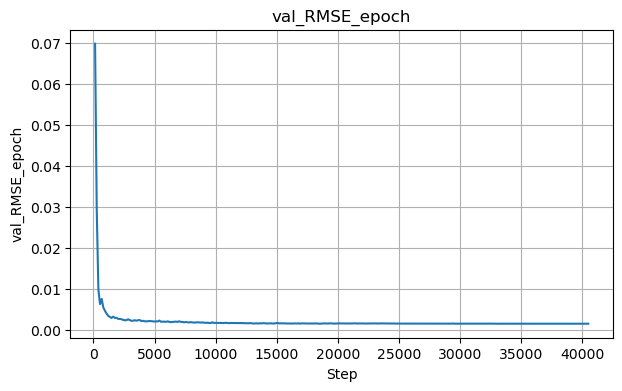

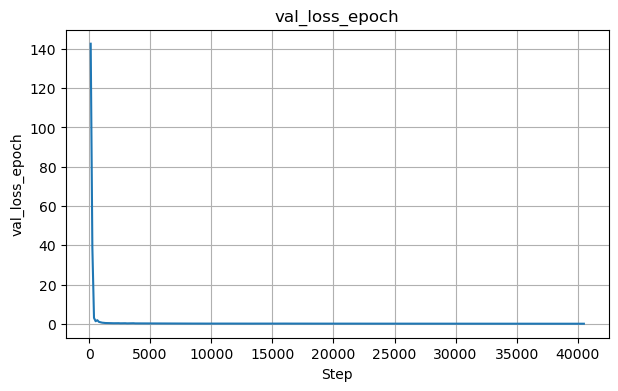

In [13]:
plot_tag(df_logs, "val_RMSE_epoch")
plot_tag(df_logs, "val_loss_epoch")

# Multi-step model eval

4.020076751708984 -4.00034761428833
memory 10 sample id: 0596
Full input shape torch.Size([1, 101, 2, 128, 128])
torch.Size([1, 10, 2, 128, 128])93664e+16     
torch.Size([1, 20, 128, 128])
10
Average RMSE: nan


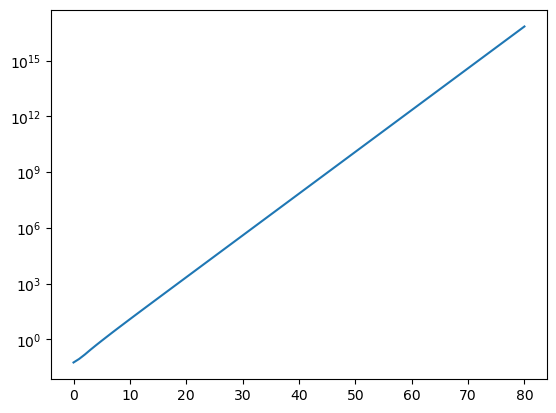

In [36]:
from utils import plot_interactive, plot_comparison, get_simulation_by_id
# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
sample_id = val_set.sample_ids[0]
full_inputs = get_simulation_by_id(datapath, sample_id).to("cuda")

print(full_inputs.max().item(), full_inputs.min().item())
full_inputs = (full_inputs + shift) * scale
full_inputs = full_inputs.unsqueeze(0).to(device)

t_norm = 101
pred_list = []
RMSE_list = []

memory = steps
print("memory", memory, "sample id:", sample_id)
print("Full input shape", full_inputs.shape)
# print(residual)
residual = True
start_idx = 5

# Prepare initial input: take first 2 slices and add batch dim
# Shape: [1, 2, C, H, W] (Batch, Sequence, Channels, Height, Width)
current_input = full_inputs[:, start_idx:start_idx + memory]
time_idx = torch.FloatTensor([start_idx + memory - 1])
time_idx = time_idx.unsqueeze(0).to(device)
model = lightning_model.model.to(device)

with torch.no_grad():
    for t in range(start_idx + 1, 100):

        current_time = (time_idx + t + 1) / t_norm

        # Reshape to [Batch, 2*C, H, W] for the model
        B, S, C, H, W = current_input.shape
        model_input = current_input.reshape(B, S * C, H, W)

        # Predict next frame: returns [B, C, H, W]
        preds = model(model_input) #, time=current_time)
        if not residual:
            preds = full_inputs[:, t, ...] + model.dt * preds
        RMSE_list.append(torch.sqrt(torch.mean((preds - full_inputs[:, t+1, ...]) ** 2)).item())
        print(f"Iteration {t}, error {RMSE_list[-1]}    ", end="\r")
        pred_list.append(preds.squeeze(0).cpu()) # Store on CPU to save VRAM

        # Rolling window: remove oldest, append newest
        # We unsqueeze(1) to get [B, 1, C, H, W] before concat
        current_input = torch.cat([
            current_input[:, 1:, ...],
            preds.unsqueeze(1)
        ], dim=1)
print(current_input.shape)
print(model_input.shape)
print(train_config.n_slices)
plt.plot(RMSE_list)
plt.yscale('log')
targets = full_inputs[:, start_idx + memory + 1:, ...]
print("Average RMSE:", np.mean(RMSE_list))

In [40]:
for name, p in model.named_parameters():
    print(name, p.abs().mean().item(), p.abs().max().item())
    break

lifting.weight 0.1503906548023224 0.4422476291656494


In [14]:
from utils import plot_interactive, plot_comparison, get_simulation_by_id
# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
sample_id = val_set.sample_ids[0]
full_inputs = get_simulation_by_id(datapath, sample_id).to("cuda")

print(full_inputs.max().item(), full_inputs.min().item())
full_inputs = (full_inputs + shift) * scale
full_inputs = full_inputs.unsqueeze(0).to(device)

t_norm = 101
pred_list = []
RMSE_list = []

memory = steps
print("memory", memory, "sample id:", sample_id)
print("Full input shape", full_inputs.shape)
# print(residual)
start_idx = 5

# Prepare initial input: take first 2 slices and add batch dim
# Shape: [1, 2, C, H, W] (Batch, Sequence, Channels, Height, Width)
current_input = full_inputs[:, start_idx:start_idx + memory]

with torch.no_grad():
    for t in range(start_idx + memory - 1, 99):

        B, S, C, H, W = current_input.shape
        model_input = current_input.reshape(B, S * C, H, W)

        derivative = model(model_input)

        preds = current_input[:, -1, ...] + model.dt * derivative

        target = full_inputs[:, t + 1, ...]

        rmse = torch.sqrt(torch.mean((preds - target) ** 2)).item()
        RMSE_list.append(rmse)

        pred_list.append(preds.squeeze(0).cpu())

        current_input = torch.cat(
            [current_input[:, 1:, ...], preds.unsqueeze(1)],
            dim=1
        )

plt.plot(RMSE_list)
plt.yscale('log')
targets = full_inputs[:, start_idx + memory + 1:, ...]
print("Average RMSE:", np.mean(RMSE_list))

4.020076751708984 -4.00034761428833
memory 10 sample id: 0596
Full input shape torch.Size([1, 101, 2, 128, 128])
after lifting: mu=5.94e-02, var=1.00e+00
kernel coord mu=-1.64e-02, var=9.14e-01
signal kernel mu=-5.28e-03, var=4.26e-02
concat kernel mu=-1.09e-02, var=4.78e-01
kernel after mixing: mu=2.19e-03, var=4.68e-02
kernel: mu=2.19e-03, var=4.68e-02
after IT: mu=-2.59e-03, var=3.63e+00
after ATT: module 0 mu=4.17e-03, var=3.25e+00
after ATT: module 1 mu=-5.35e-02, var=3.29e+00
after ATT: module 2 mu=-7.47e-02, var=3.71e+00
after ATT: module 3 mu=-1.38e-02, var=4.29e+00
after REC: mu=2.21e-03, var=2.64e-03
Final: mu=-3.93e-03, var=2.10e-04


AttributeError: 'ITLNO' object has no attribute 'dt'

Save dir: /home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/ITLNO/10steps_20260617-105424/visualization
Original max/min: 4.020076751708984 -4.00034761428833
Full input shape: torch.Size([1, 101, 2, 128, 128])
memory: 10 sample id: 0596
after lifting: mu=5.94e-02, var=1.00e+00
kernel coord mu=-1.64e-02, var=9.14e-01
signal kernel mu=-5.28e-03, var=4.26e-02
concat kernel mu=-1.09e-02, var=4.78e-01
kernel after mixing: mu=2.19e-03, var=4.68e-02
kernel: mu=2.19e-03, var=4.68e-02
after IT: mu=-2.59e-03, var=3.63e+00
after ATT: module 0 mu=4.17e-03, var=3.25e+00
after ATT: module 1 mu=-5.35e-02, var=3.29e+00
after ATT: module 2 mu=-7.47e-02, var=3.71e+00
after ATT: module 3 mu=-1.38e-02, var=4.29e+00
after REC: mu=2.21e-03, var=2.64e-03
Final: mu=-3.93e-03, var=2.10e-04
after lifting: mu=5.95e-02, var=1.00e+00
kernel coord mu=-1.64e-02, var=9.14e-01
signal kernel mu=-5.00e-03, var=4.04e-02
concat kernel mu=-1.07e-02, var=4.77e-01
kernel after mixing: mu=1.63e-03, var=4.59e-0

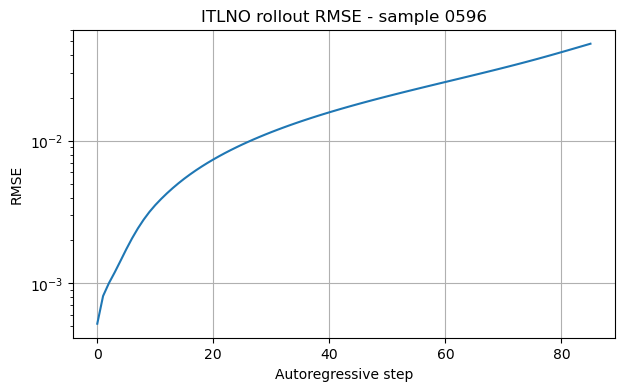

Saved figure: /home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/ITLNO/10steps_20260617-105424/visualization/figures/ITLNO_sample_0596_rmse.png


In [15]:
from utils import get_simulation_by_id

# -------------------------
# Setup
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# model_name = "FNO"  # change if needed
sample_id = val_set.sample_ids[0]

start_idx = 5
memory = steps          # should be 10 from hyperparams
t_norm = 101
end_t = 100             # last t used, predicts until frame 100

residual = False        # from your training logic

# Save directory

(save_dir / "npy").mkdir(parents=True, exist_ok=True)
(save_dir / "figures").mkdir(parents=True, exist_ok=True)
(save_dir / "metrics").mkdir(parents=True, exist_ok=True)

print("Save dir:", save_dir)

# -------------------------
# Load full simulation
# -------------------------
full_inputs = get_simulation_by_id(datapath, sample_id).to(device)

print("Original max/min:", full_inputs.max().item(), full_inputs.min().item())

full_inputs = (full_inputs + shift) * scale
full_inputs = full_inputs.unsqueeze(0).to(device)

print("Full input shape:", full_inputs.shape)
print("memory:", memory, "sample id:", sample_id)

# -------------------------
# Prepare model
# -------------------------
model = lightning_model.model.to(device)
model.eval()

dt = lightning_model.dt

# -------------------------
# Rollout
# -------------------------
current_input = full_inputs[:, start_idx:start_idx + memory]

pred_list = []
RMSE_list = []

with torch.no_grad():
    for t in range(start_idx + memory - 1, end_t):

        B, S, C, H, W = current_input.shape
        model_input = current_input.reshape(B, S * C, H, W)

        derivative = model(model_input)

        preds = current_input[:, -1, ...] + dt * derivative
        target = full_inputs[:, t + 1, ...]

        if not torch.isfinite(preds).all():
            print("Non-finite prediction at t =", t)
            break

        rmse = torch.sqrt(torch.mean((preds - target) ** 2)).item()
        RMSE_list.append(rmse)

        print(f"t={t}, RMSE={rmse:.4e}", end="\r")

        pred_list.append(preds.squeeze(0).cpu())

        current_input = torch.cat(
            [current_input[:, 1:, ...], preds.unsqueeze(1)],
            dim=1
        )

print()
print("Finite steps:", len(RMSE_list))

# -------------------------
# Convert to arrays
# -------------------------
pred_arr = torch.stack(pred_list).numpy()
gt_arr = full_inputs[:, start_idx + memory:end_t + 1].squeeze(0).cpu().numpy()
rmse_arr = np.array(RMSE_list)

print("pred_arr shape:", pred_arr.shape)
print("gt_arr shape:", gt_arr.shape)
print("Average RMSE:", rmse_arr.mean())

# -------------------------
# Save numerical results
# -------------------------
npz_path = save_dir / "npy" / f"{model_name}_sample_{sample_id}_rollout.npz"

np.savez(
    npz_path,
    pred=pred_arr,
    gt=gt_arr,
    rmse=rmse_arr,
    sample_id=sample_id,
    model_name=model_name,
    start_idx=start_idx,
    memory=memory,
    shift=shift,
    scale=scale,
    dt=dt,
)

print("Saved:", npz_path)

# -------------------------
# Save RMSE plot
# -------------------------
plt.figure(figsize=(7, 4))
plt.plot(rmse_arr)
plt.yscale("log")
plt.xlabel("Autoregressive step")
plt.ylabel("RMSE")
plt.title(f"{model_name} rollout RMSE - sample {sample_id}")
plt.grid(True)

fig_path = save_dir / "figures" / f"{model_name}_sample_{sample_id}_rmse.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

# Visualization

In [ ]:
p = torch.stack(pred_list).detach().cpu()
# g = full_inputs[0, start_idx + memory:].detach().cpu()
g = targets[0].detach().cpu()
plot_interactive(p, g, channel_idx=0)

In [ ]:
plt.rc('animation', html='jshtml')
anim = animate_results_mpl(p, g, channel_idx=0)
anim


# Satistics
Compute some statistics on the dataset

In [ ]:
datapath = Path("/media/jlux/SSD2/pdebench/2d_reaction_diffusion/133017.hdf5")
sample_id = train_set.sample_ids[20]
full_inputs = get_simulation_by_id(datapath, sample_id).to("cuda")

print(full_inputs.shape)
print(full_inputs.max().item(), full_inputs.min().item())
print(scale, shift)
dt = 5/100.
full_inputs = (full_inputs + shift) * scale
delta = torch.abs(full_inputs[1:, ...] - full_inputs[:-1, ...]) / dt
delta_mean = torch.mean(delta, dim=(1,2,3))

mean_per_frame = torch.mean(full_inputs, dim=(1,2,3))
std_per_frame = torch.mean(full_inputs**2, dim=(1,2,3)) - mean_per_frame**2
std_total = delta.std()
# print(torch.sqrt(std_per_frame))
print(std_total.item())

delta_max = torch.amax(delta, dim=(1,2,3))
delta_min = torch.amin(delta, dim=(1,2,3))
print(delta_max)
print(delta_min)

vrange = torch.amax(full_inputs, dim=(1,2,3)) - torch.amin(full_inputs,dim=(1,2,3))
plt.plot(torch.sqrt(std_per_frame).cpu().numpy(), label='std')
# plt.plot(mean_per_frame.abs().cpu().numpy(), label='mean')
# plt.plot(vrange.abs().cpu().numpy(), label='range')
plt.plot(delta_mean.cpu().numpy(), label='mean')
plt.plot(delta_min.cpu().numpy(), label='min')
plt.plot(delta_max.cpu().numpy(), label='max')
plt.yscale("log")
plt.legend()
print(vrange.mean().item(), std_per_frame.mean().item(), mean_per_frame.mean().item())

# vis

In [17]:
def run_rollout_and_save_pngs_supervisor(
    lightning_model,
    datapath,
    sample_id,
    save_dir,
    steps,
    shift=0,
    scale=1,
    start_idx=5,
    end_idx=100,
    device=None,
    channel_names=(r"$u$", r"$v$"),
    cmap="viridis",
    dpi=300,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    save_dir = Path(save_dir)
    fig_dir = save_dir / "png_frames"
    npy_dir = save_dir / "npy"
    fig_dir.mkdir(parents=True, exist_ok=True)
    npy_dir.mkdir(parents=True, exist_ok=True)

    # Load full trajectory: [T, C, H, W]
    full_inputs = get_simulation_by_id(datapath, sample_id).float().to(device)
    full_inputs = (full_inputs + shift) * scale
    full_inputs = full_inputs.unsqueeze(0)  # [1, T, C, H, W]

    print("Statistics of the trajectory:")
    print(
        f"Max: {full_inputs.max().item()} \n"
        f"Min: {full_inputs.min().item()} \n"
        f"Var: {full_inputs.var().item()} \n"
        f"Mean: {full_inputs.mean().item()}"
    )

    model = lightning_model.model.to(device)
    model.eval()
    dt = lightning_model.dt

    memory = steps
    current_input = full_inputs[:, start_idx:start_idx + memory]

    pred_list = []
    gt_list = []
    abs_error_list = []
    rmse_list = []
    rmse_over_std_list = []
    timestep_list = []

    print("memory:", memory, "sample id:", sample_id)
    print("full input shape:", full_inputs.shape)
    print("initial input shape:", current_input.shape)

    with torch.no_grad():
        for t in range(start_idx + memory - 1, end_idx):

            B, S, C, H, W = current_input.shape
            model_input = current_input.reshape(B, S * C, H, W)

            derivative = model(model_input)
            preds = current_input[:, -1, ...] + dt * derivative

            target_idx = t + 1
            gt = full_inputs[:, target_idx, ...]

            if not torch.isfinite(preds).all():
                print("Non-finite prediction at timestep:", target_idx)
                break

            abs_error = torch.abs(gt - preds)

            rmse = torch.sqrt(torch.mean((preds - gt) ** 2)).item()
            rmse_over_std = rmse / (gt.std().item() + 1e-12)

            rmse_list.append(rmse)
            rmse_over_std_list.append(rmse_over_std)
            timestep_list.append(target_idx)

            pred_cpu = preds.squeeze(0).detach().cpu()
            gt_cpu = gt.squeeze(0).detach().cpu()
            err_cpu = abs_error.squeeze(0).detach().cpu()

            pred_list.append(pred_cpu)
            gt_list.append(gt_cpu)
            abs_error_list.append(err_cpu)

            print(
                f"t={target_idx}, RMSE={rmse:.2e}, "
                f"RMSE/std={rmse_over_std:.2e}",
                end="\r"
            )

            save_single_timestep_png(
                pred_cpu,
                gt_cpu,
                err_cpu,
                save_path=fig_dir / f"frame_t{target_idx:04d}.png",
                timestep=target_idx,
                rmse=rmse,
                channel_names=channel_names,
                cmap=cmap,
                dpi=dpi,
            )

            current_input = torch.cat(
                [current_input[:, 1:, ...], preds.unsqueeze(1)],
                dim=1
            )

    print()

    pred_arr = torch.stack(pred_list, dim=0).numpy()
    gt_arr = torch.stack(gt_list, dim=0).numpy()
    err_arr = torch.stack(abs_error_list, dim=0).numpy()
    rmse_arr = np.array(rmse_list)
    rmse_std_arr = np.array(rmse_over_std_list)

    np.save(npy_dir / "prediction.npy", pred_arr)
    np.save(npy_dir / "ground_truth.npy", gt_arr)
    np.save(npy_dir / "absolute_error.npy", err_arr)
    np.save(npy_dir / "timesteps.npy", np.array(timestep_list))
    np.save(npy_dir / "rmse.npy", rmse_arr)
    np.save(npy_dir / "rmse_over_std.npy", rmse_std_arr)

    np.savez(
        npy_dir / "rollout_results.npz",
        prediction=pred_arr,
        ground_truth=gt_arr,
        absolute_error=err_arr,
        timesteps=np.array(timestep_list),
        rmse=rmse_arr,
        rmse_over_std=rmse_std_arr,
        sample_id=sample_id,
        steps=steps,
        start_idx=start_idx,
        end_idx=end_idx,
        shift=shift,
        scale=scale,
        dt=dt,
    )

    df = pd.DataFrame({
        "Timestep": timestep_list,
        "RMSE": rmse_list,
        "RMSE_over_STD": rmse_over_std_list,
    })

    df.to_csv(save_dir / "RMSE.csv", index=False)

    plt.figure(figsize=(6, 4))
    plt.plot(timestep_list, rmse_list, marker="o")
    plt.yscale("log")
    plt.xlabel("Timestep")
    plt.ylabel("RMSE")
    plt.title(f"Autoregressive Rollout Error - sample {sample_id}")
    plt.tight_layout()
    plt.savefig(save_dir / "RMSE_plot.png", dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Average RMSE:", np.mean(rmse_list))
    print("Average RMSE/STD:", np.mean(rmse_over_std_list))
    print("Saved results to:", save_dir)

    return pred_arr, gt_arr, err_arr, df


from matplotlib.colors import LogNorm


def save_single_timestep_png(
    pred,
    gt,
    error,
    save_path,
    timestep,
    rmse,
    channel_names=(r"$u$", r"$v$"),
    cmap="viridis",
    error_cmap="magma",
    dpi=300,
    error_vmin=1e-8,
    error_vmax=1e-1,
):
    """
    pred, gt, error: [C, H, W]

    Shared logarithmic error colorbar across all plots.
    """

    C = pred.shape[0]

    fig, axes = plt.subplots(
        C,
        3,
        figsize=(10, 3.5 * C),
        constrained_layout=True
    )

    if C == 1:
        axes = axes[None, :]

    # shared log normalization
    err_norm = LogNorm(
        vmin=error_vmin,
        vmax=error_vmax
    )

    for c in range(C):

        gt_c = gt[c].numpy()
        pred_c = pred[c].numpy()
        err_c = error[c].numpy()

        # shared physical scale
        vmin = min(gt_c.min(), pred_c.min())
        vmax = max(gt_c.max(), pred_c.max())

        im0 = axes[c, 0].imshow(
            gt_c,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )

        axes[c, 0].set_title("Ground Truth")
        axes[c, 0].set_ylabel(
            channel_names[c] if c < len(channel_names) else f"ch {c}",
            fontsize=14
        )

        im1 = axes[c, 1].imshow(
            pred_c,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin="lower"
        )

        axes[c, 1].set_title("Prediction")

        im2 = axes[c, 2].imshow(
            np.clip(err_c, error_vmin, None),
            cmap=error_cmap,
            norm=err_norm,
            origin="lower"
        )

        axes[c, 2].set_title("Abs Error (log)")

        for j in range(3):
            axes[c, j].set_xticks([])
            axes[c, j].set_yticks([])

        # field colorbars
        cbar0 = fig.colorbar(
            im0,
            ax=axes[c, 0],
            fraction=0.046,
            pad=0.04
        )

        cbar1 = fig.colorbar(
            im1,
            ax=axes[c, 1],
            fraction=0.046,
            pad=0.04
        )

        # shared error colorbar
        cbar2 = fig.colorbar(
            im2,
            ax=axes[c, 2],
            fraction=0.046,
            pad=0.04
        )

    fig.suptitle(
        f"Timestep {timestep} | RMSE = {rmse:.4e}",
        fontsize=16
    )

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

Statistics of the trajectory:
Max: 4.020076751708984 
Min: -4.00034761428833 
Var: 0.016465237364172935 
Mean: -0.013801464810967445
memory: 10 sample id: 0596
full input shape: torch.Size([1, 101, 2, 128, 128])
initial input shape: torch.Size([1, 10, 2, 128, 128])
after lifting: mu=5.94e-02, var=1.00e+00
kernel coord mu=-1.64e-02, var=9.14e-01
signal kernel mu=-5.28e-03, var=4.26e-02
concat kernel mu=-1.09e-02, var=4.78e-01
kernel after mixing: mu=2.19e-03, var=4.68e-02
kernel: mu=2.19e-03, var=4.68e-02
after IT: mu=-2.59e-03, var=3.63e+00
after ATT: module 0 mu=4.17e-03, var=3.25e+00
after ATT: module 1 mu=-5.35e-02, var=3.29e+00
after ATT: module 2 mu=-7.47e-02, var=3.71e+00
after ATT: module 3 mu=-1.38e-02, var=4.29e+00
after REC: mu=2.21e-03, var=2.64e-03
Final: mu=-3.93e-03, var=2.10e-04
after lifting: mu=5.95e-02, var=1.00e+00
kernel coord mu=-1.64e-02, var=9.14e-01
signal kernel mu=-5.00e-03, var=4.04e-02
concat kernel mu=-1.07e-02, var=4.77e-01
kernel after mixing: mu=1.63e-03

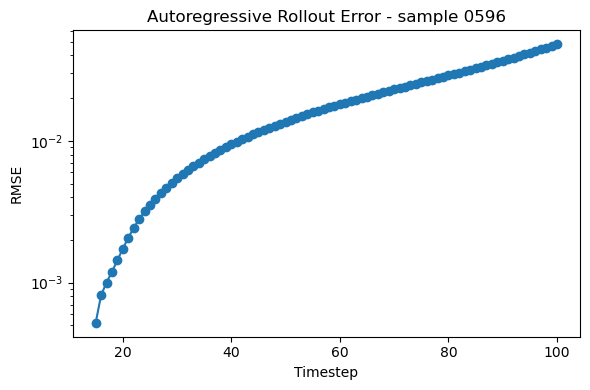

Average RMSE: 0.018898544076364487
Average RMSE/STD: 0.20827127817511829
Saved results to: /home/armature/Codes/model_checkpoints/new_pdebench/PDEBENCH/run1/ITLNO/10steps_20260617-105424/visualization


In [18]:
# model_name = "FNO"
# sample_id = "0596"

# save_dir = Path("./visualization") / model_name / f"sample_{sample_id}"

pred_arr, gt_arr, err_arr, df = run_rollout_and_save_pngs_supervisor(
    lightning_model=lightning_model,
    datapath=datapath,
    sample_id=sample_id,
    save_dir=save_dir,
    steps=hyperparams["steps"],
    shift=hyperparams["shift"],
    scale=hyperparams["scale"],
    start_idx=5,
    end_idx=100,
    device=device,
    channel_names=(r"$u$", r"$v$"),
)

# END